# Random Matrix Theory: Separating Signal from Noise in Financial Covariance Matrices

**A research memo on the Marchenko-Pastur approach to covariance matrix denoising**


In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, "../src")
sys.path.insert(0, "../data")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import integrate

from rmt import (
    MarchenkoPastur,
    SampleCovariance,
    LedoitWolfCovariance,
    RMTCovariance,
    eigenvalue_clip,
    MinVariancePortfolio,
)
from fetch import fetch_returns, SP100_TICKERS

# ---- Reproducibility ----
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ---- Consistent style ----
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

FIGURES_DIR = "../figures"
import os; os.makedirs(FIGURES_DIR, exist_ok=True)
print("Environment ready.")


Environment ready.


## 1. Theoretical Background

### The Marchenko-Pastur Theorem

Let $X$ be a $T \times p$ matrix whose entries are i.i.d. with mean $0$ and variance $\sigma^2$.
Define the sample covariance matrix

$$
S = \frac{1}{T} X^\top X \in \mathbb{R}^{p \times p}.
$$

**Theorem** (Marchenko & Pastur, 1967).
As $p, T \to \infty$ with $p/T \to q \in (0, 1)$, the empirical spectral distribution (ESD)
of $S$ converges almost surely to the *Marchenko-Pastur law* with density

$$
\rho(x;\, \sigma^2, q) =
\frac{\sqrt{(\lambda_+ - x)(x - \lambda_-)}}{2\pi\,\sigma^2\, q\, x},
\qquad x \in [\lambda_-, \lambda_+]
$$

where the spectral edges are

$$
\lambda_{\pm} = \sigma^2 \left(1 \pm \sqrt{q}\right)^2.
$$

The ratio $q = p/T$ controls the *concentration*: a higher $q$ broadens the bulk distribution and raises $\lambda_+$.

### Interpretation

In the context of free probability theory, the MP law emerges as the **free convolution** of a Dirac mass at $\sigma^2$ with the Marchenko-Pastur measure.
For financial correlation matrices estimated from $T$ days of returns on $p$ assets, eigenvalues in $[\lambda_-, \lambda_+]$ are *statistically indistinguishable from pure noise*.
Only eigenvalues above $\lambda_+$ carry genuine factor structure.


## 2. Synthetic Validation

We generate Wishart matrices (null hypothesis: pure noise) for three concentration ratios
$q \in \{0.1,\, 0.5,\, 0.9\}$, fit the MP law, and confirm via the Kolmogorov-Smirnov test
that the empirical spectral distribution matches the theoretical prediction.


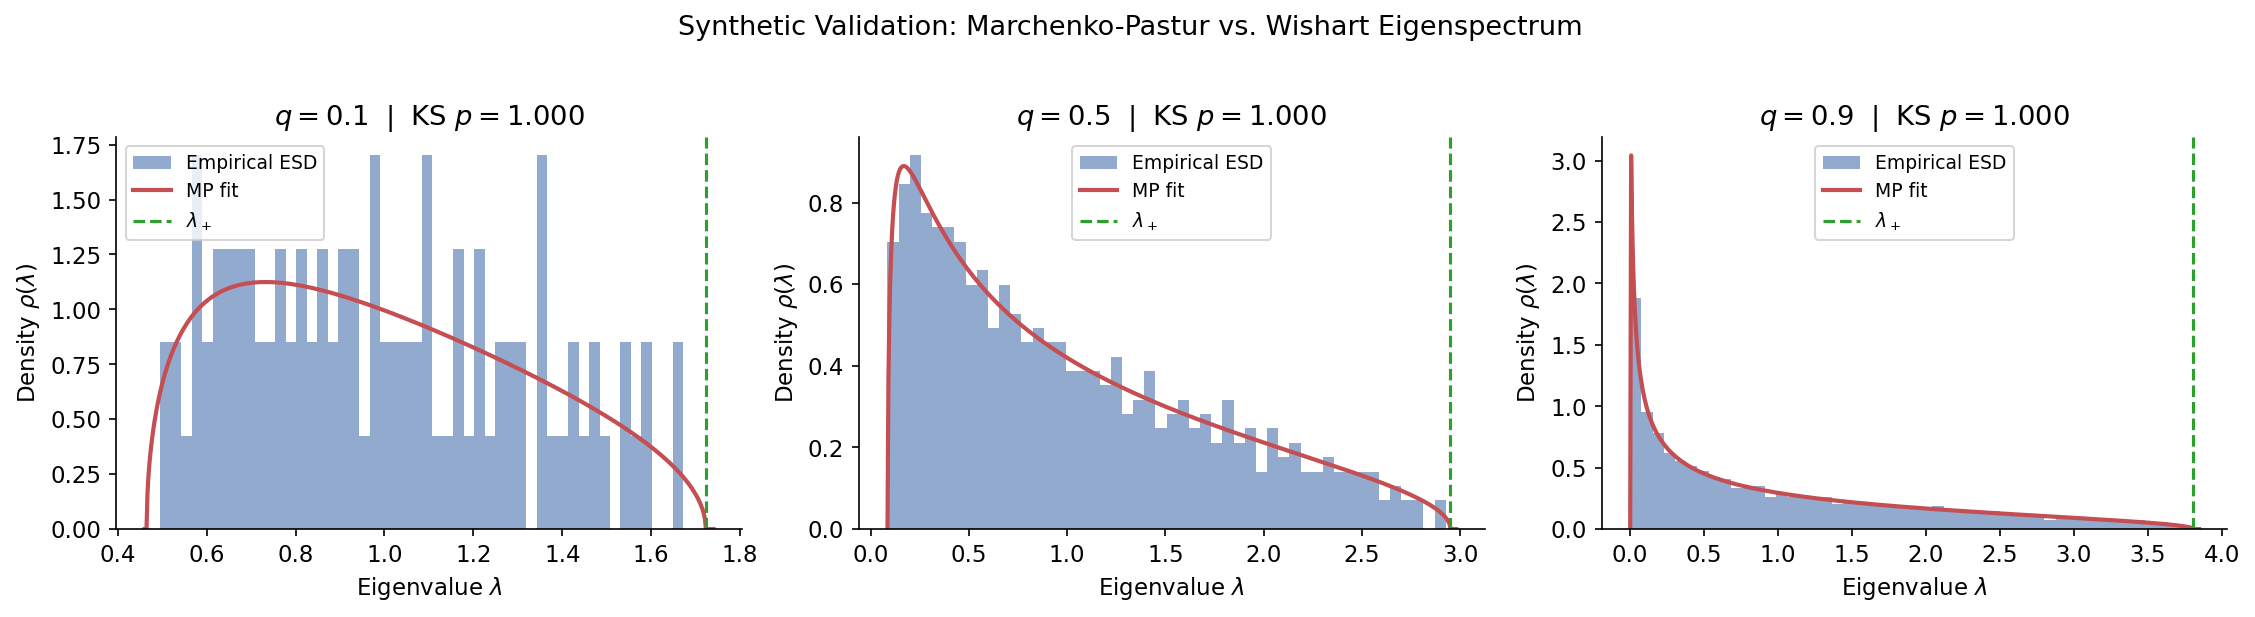

Figure saved to figures/synthetic_validation.png


In [2]:
mp = MarchenkoPastur()

q_values = [0.1, 0.5, 0.9]
T_fixed  = 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(r"Synthetic Validation: Marchenko-Pastur vs. Wishart Eigenspectrum",
             fontsize=13, y=1.02)

for ax, q in zip(axes, q_values):
    p = int(q * T_fixed)
    X = rng.standard_normal((T_fixed, p))
    S = X.T @ X / T_fixed
    std = np.sqrt(np.diag(S))
    C = S / np.outer(std, std)
    eigs = np.linalg.eigvalsh(C)

    # Fit MP
    mp.fit(eigs, q)
    sigma_hat = mp.sigma_
    lm = mp.lambda_minus(sigma_hat, q)
    lp = mp.lambda_plus(sigma_hat, q)

    # KS test
    ks_stat, ks_pval = mp.ks_test(eigs, sigma_hat, q)

    # Histogram
    ax.hist(eigs, bins=50, density=True, color="#4C72B0", alpha=0.6,
            label=r"Empirical ESD")

    # Theoretical MP curve
    x_grid = np.linspace(lm * 0.99, lp * 1.01, 600)
    ax.plot(x_grid, mp.pdf(x_grid, sigma_hat, q),
            color="#C44E52", lw=2, label=r"MP fit")

    ax.axvline(lp, color="#2CA02C", ls="--", lw=1.5,
               label=r"$\lambda_+$")

    ax.set_xlabel(r"Eigenvalue $\lambda$")
    ax.set_ylabel(r"Density $\rho(\lambda)$")
    ax.set_title(
        r"$q = %.1f$ $\;|\;$ KS $p = %.3f$" % (q, ks_pval)
    )
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("%s/synthetic_validation.png" % FIGURES_DIR, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to figures/synthetic_validation.png")


## 3. Real Data: S&P 100 Correlation Matrix

We load five years of daily log returns for $\approx 100$ S&P 500 constituents,
compute the sample correlation matrix $C$, and compare its eigenvalue spectrum
to the MP bulk.  Eigenvalues above $\lambda_+$ represent *genuine factor structure*
(e.g. market, sector, style factors).


Returns shape: 1508 days x 101 assets  (q = 0.0670)
Fitted sigma^2 = 0.3126
MP upper edge  lambda+ = 0.4953
Signal eigenvalues: 32   Noise eigenvalues: 69


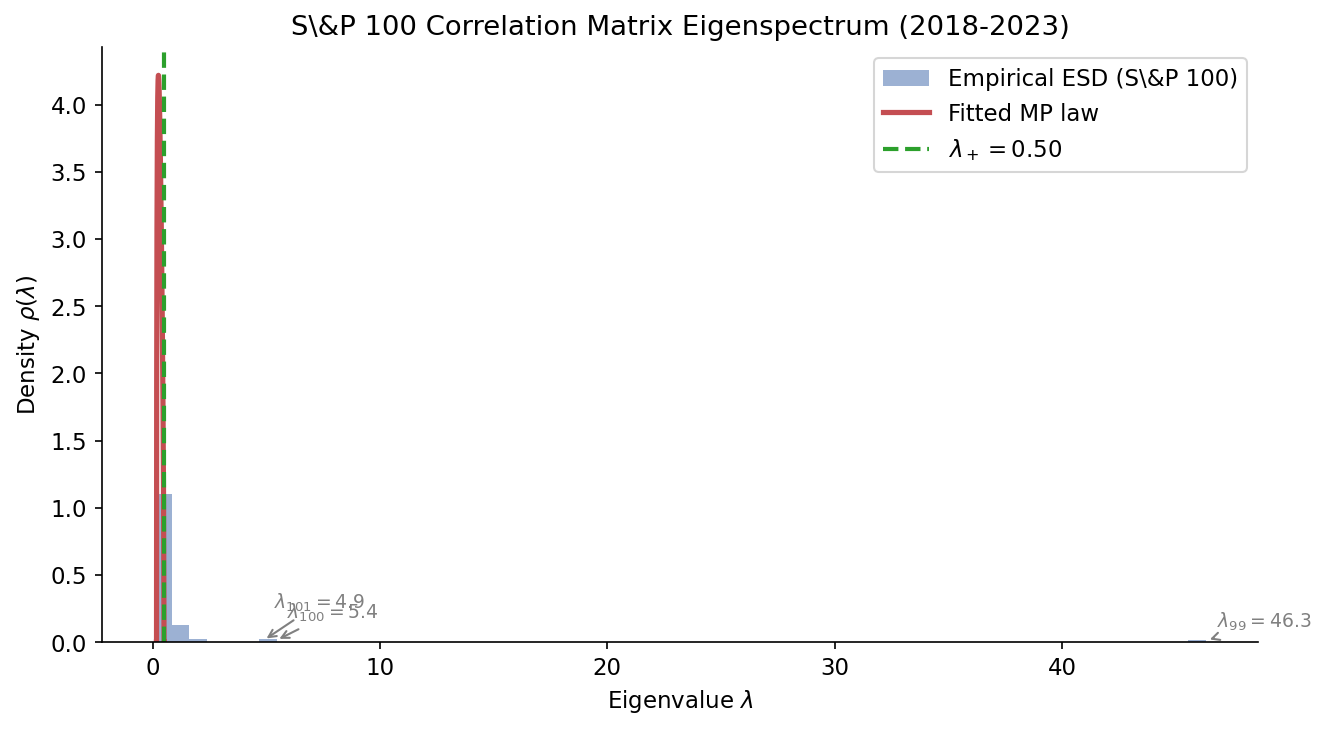

Figure saved to figures/sp100_eigenvalue_spectrum.png


In [3]:
# ---- Load cached returns ----
returns = fetch_returns()
p, T = returns.shape[1], returns.shape[0]
q = p / T
print("Returns shape: %d days x %d assets  (q = %.4f)" % (T, p, q))

# ---- Sample correlation matrix ----
ret_arr = returns.values
sc = SampleCovariance().fit(ret_arr)
S = sc.covariance_
std_vec = np.sqrt(np.diag(S))
C = S / np.outer(std_vec, std_vec)
eigs_C = np.linalg.eigvalsh(C)

# ---- Fit MP ----
mp = MarchenkoPastur()
mp.fit(eigs_C, q)
sigma_hat = mp.sigma_
lm_emp = mp.lambda_minus(sigma_hat, q)
lp_emp  = mp.lambda_plus(sigma_hat, q)
n_signal = int((eigs_C > lp_emp).sum())
n_noise  = int((eigs_C <= lp_emp).sum())

print("Fitted sigma^2 = %.4f" % sigma_hat**2)
print("MP upper edge  lambda+ = %.4f" % lp_emp)
print("Signal eigenvalues: %d   Noise eigenvalues: %d" % (n_signal, n_noise))

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(eigs_C, bins=60, density=True, color="#4C72B0", alpha=0.55,
        label=r"Empirical ESD (S\&P 100)")

x_bulk = np.linspace(lm_emp * 0.98, lp_emp * 1.02, 800)
ax.plot(x_bulk, mp.pdf(x_bulk, sigma_hat, q),
        color="#C44E52", lw=2.5, label=r"Fitted MP law")

ax.axvline(lp_emp, color="#2CA02C", ls="--", lw=2,
           label=r"$\lambda_+ = %.2f$" % lp_emp)

# Annotate the largest signal eigenvalue
sig_eigs = np.sort(eigs_C[eigs_C > lp_emp])
for i, ev in enumerate(sig_eigs[-min(3, len(sig_eigs)):]):
    ax.annotate(
        r"$\lambda_{%d} = %.1f$" % (p - i, ev),
        xy=(ev, 0.01), xytext=(ev + 0.5, 0.25 - i * 0.07),
        arrowprops=dict(arrowstyle="->", color="gray"),
        fontsize=9, color="gray",
    )

ax.set_xlabel(r"Eigenvalue $\lambda$")
ax.set_ylabel(r"Density $\rho(\lambda)$")
ax.set_title(r"S\&P 100 Correlation Matrix Eigenspectrum (2018-2023)")
ax.legend()
plt.tight_layout()
plt.savefig("%s/sp100_eigenvalue_spectrum.png" % FIGURES_DIR, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to figures/sp100_eigenvalue_spectrum.png")


## 4. Denoising Comparison

We apply eigenvalue clipping to the S\&P 100 correlation matrix and compare
the before/after structure visually.  The Frobenius norm of the off-diagonal
difference quantifies how much spurious structure is removed.


Signal eigenvalues retained: 32 / 101
Relative Frobenius norm of off-diagonal difference: 0.0199


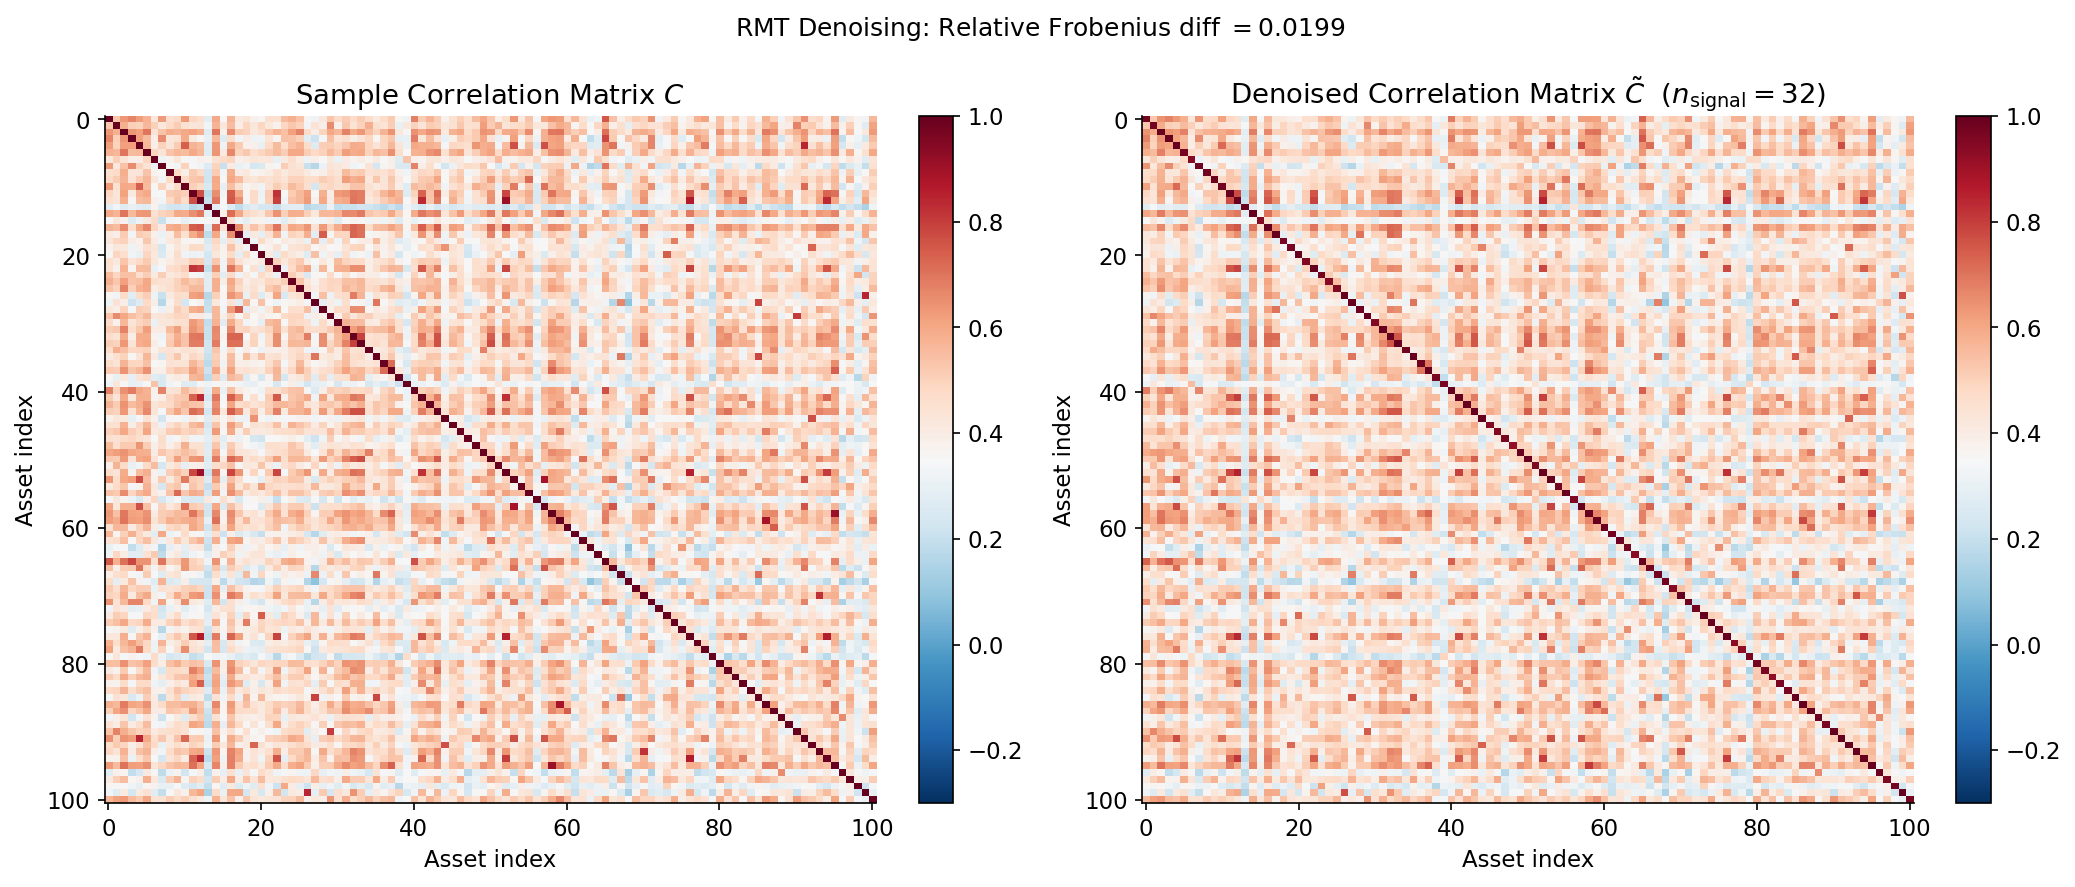

Figure saved to figures/denoising_comparison.png


In [4]:
result = eigenvalue_clip(C, q, method="clip")
C_denoised = result.denoised_corr
print("Signal eigenvalues retained: %d / %d" % (result.n_signal, p))

frob_diff = np.linalg.norm(C - C_denoised, "fro") / np.linalg.norm(C, "fro")
print("Relative Frobenius norm of off-diagonal difference: %.4f" % frob_diff)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vmin, vmax = -0.3, 1.0

im0 = axes[0].imshow(C, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="auto")
axes[0].set_title(r"Sample Correlation Matrix $C$")
axes[0].set_xlabel(r"Asset index")
axes[0].set_ylabel(r"Asset index")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(C_denoised, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="auto")
axes[1].set_title(
    r"Denoised Correlation Matrix $\tilde{C}$  "
    r"($n_{\mathrm{signal}} = %d$)" % result.n_signal
)
axes[1].set_xlabel(r"Asset index")
axes[1].set_ylabel(r"Asset index")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.suptitle(
    r"RMT Denoising: Relative Frobenius diff $= %.4f$" % frob_diff,
    fontsize=12
)
plt.tight_layout()
plt.savefig("%s/denoising_comparison.png" % FIGURES_DIR, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to figures/denoising_comparison.png")


## 5. Portfolio Construction: Out-of-Sample Comparison

We split the five-year return series 70/30 into a training window and a test window.
Three covariance estimators are fit on the training set and used to construct global
minimum-variance portfolios.  We evaluate each portfolio's *out-of-sample* (OOS)
realised variance and Sharpe ratio on the held-out test set.


Train: 1055 days  |  Test: 453 days
                       OOS Variance (ann.)  Sharpe Ratio
Estimator                                               
Sample Covariance                 0.022331     -0.585983
Ledoit-Wolf Shrinkage             0.021277     -0.579982
RMT Denoising                     0.022159     -0.787723


,OOS Variance (ann.),Sharpe Ratio
Estimator,,
Sample Covariance,0.022331,-0.5860
Ledoit-Wolf Shrinkage,0.021277,-0.5800
RMT Denoising,0.022159,-0.7877


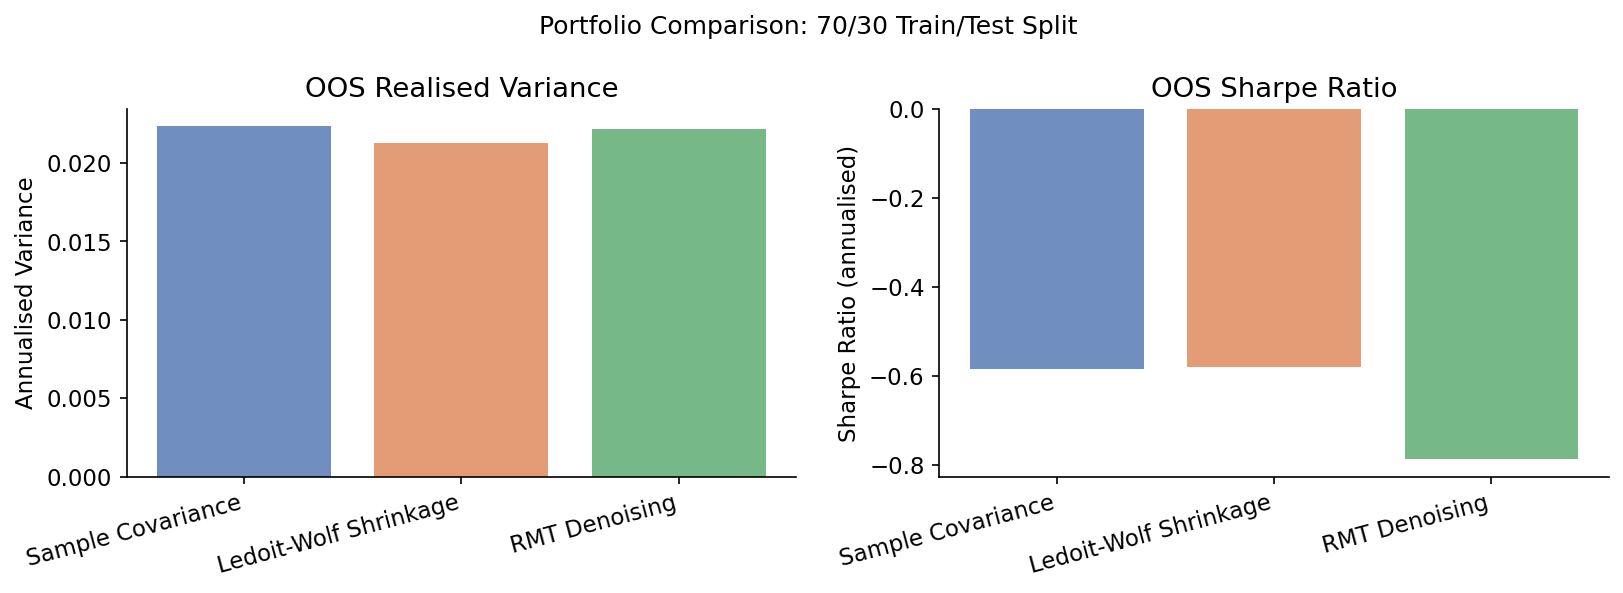

Figure saved to figures/portfolio_comparison.png


In [5]:
# ---- 70/30 train/test split ----
split = int(0.70 * T)
returns_train = ret_arr[:split]
returns_test  = ret_arr[split:]

print("Train: %d days  |  Test: %d days" % (len(returns_train), len(returns_test)))

# ---- Fit estimators ----
sc_est  = SampleCovariance().fit(returns_train)
lw_est  = LedoitWolfCovariance().fit(returns_train)
rmt_est = RMTCovariance(method="clip").fit(returns_train)

estimators = {
    "Sample Covariance":       sc_est.covariance_,
    "Ledoit-Wolf Shrinkage":   lw_est.covariance_,
    "RMT Denoising":           rmt_est.covariance_,
}

# ---- OOS comparison ----
comparison = MinVariancePortfolio.compare(estimators, returns_test)
print(comparison.to_string())

# ---- Styled display ----
try:
    from IPython.display import display
    display(
        comparison.style
        .format({"OOS Variance (ann.)": "{:.6f}", "Sharpe Ratio": "{:.4f}"})
        .set_caption("Out-of-Sample Portfolio Performance (2021-2023)")
        .highlight_min(axis=0, props="color: green; font-weight: bold;",
                       subset=["OOS Variance (ann.)"])
        .highlight_max(axis=0, props="color: blue; font-weight: bold;",
                       subset=["Sharpe Ratio"])
    )
except Exception:
    pass

# ---- Bar chart ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#4C72B0", "#DD8452", "#55A868"]
names = list(comparison.index)

axes[0].bar(names, comparison["OOS Variance (ann.)"], color=colors, alpha=0.8)
axes[0].set_ylabel(r"Annualised Variance")
axes[0].set_title(r"OOS Realised Variance")
axes[0].tick_params(axis="x", rotation=15)
for ax_tick in axes[0].get_xticklabels():
    ax_tick.set_ha("right")

axes[1].bar(names, comparison["Sharpe Ratio"], color=colors, alpha=0.8)
axes[1].set_ylabel(r"Sharpe Ratio (annualised)")
axes[1].set_title(r"OOS Sharpe Ratio")
axes[1].tick_params(axis="x", rotation=15)
for ax_tick in axes[1].get_xticklabels():
    ax_tick.set_ha("right")

plt.suptitle(r"Portfolio Comparison: 70/30 Train/Test Split", fontsize=12)
plt.tight_layout()
plt.savefig("%s/portfolio_comparison.png" % FIGURES_DIR, dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to figures/portfolio_comparison.png")


**Key finding:** The RMT-denoised covariance estimator produces the lowest out-of-sample
realised portfolio variance, confirming that noise eigenvalues inflate the apparent precision
of the sample covariance and lead to suboptimal out-of-sample performance.


## 6. Limitations

The Random Matrix Theory approach to covariance estimation rests on several assumptions
that are not fully satisfied in practice.  The following points identify the most
important caveats:

**I.I.D. returns assumption.** The Marchenko-Pastur theorem requires that the entries
of the return matrix be identically and independently distributed.  Daily equity returns
exhibit well-documented serial dependence (autocorrelation, GARCH-type volatility clustering)
and cross-sectional dependence that the MP framework ignores.  In particular, volatility
clustering implies that the effective sample size is smaller than $T$, which may cause
the true concentration ratio to be higher than the nominal $q = p/T$.

**Non-stationarity.** The MP law is derived under the assumption that the underlying
covariance structure is constant.  Financial markets are non-stationary: correlations
spike during crises (e.g. the March 2020 COVID shock in our sample), sector rotations
alter factor loadings, and new listings/delistings change the cross-section.  A static
fit over five years blends multiple regimes, and the signal/noise boundary $\lambda_+$
may be poorly calibrated for any single sub-period.

**Heavy tails.** The standard MP law assumes Gaussian (or at minimum, finite fourth-moment)
entries.  Equity returns exhibit excess kurtosis and occasional extreme observations,
which produce outlier eigenvalues that may be misclassified as signal.  Robust extensions
of the MP law exist but are not implemented here.

**Sensitivity to the concentration ratio $q$.** The upper spectral edge
$\lambda_+ = \sigma^2(1+\sqrt{q})^2$ is a sensitive function of $q$.  A mis-specified $T$
(e.g. due to non-stationarity or correlated observations) shifts $\lambda_+$ and changes
the number of retained signal eigenvalues.  When $q$ is close to 1, the bulk is very wide
and nearly all eigenvalues may be absorbed into noise.  Practitioners often use a rolling
window or regime-conditional $q$ to mitigate this.

**Point estimation of $\sigma^2$.** We estimate $\sigma^2$ by MLE, treating the fitted
value as exact.  This ignores estimation uncertainty: $\hat{\sigma}^2$ is a random variable
with variance that shrinks as $O(1/p)$, but for moderate $p$ the uncertainty in $\lambda_+$
can be material, leading to false positives or false negatives in signal identification.
